In [ ]:
import model_library as ml
import learning_rates as lr

import numpy as np

from keras.callbacks import ModelCheckpoint

from matplotlib import pyplot as plt

from experiments import synthetic_data_alignment

from importlib import reload

2024-11-03 00:59:52.896328: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-03 00:59:52.916801: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-03 00:59:52.916820: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-03 00:59:52.917414: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-03 00:59:52.921112: I tensorflow/core/platform/cpu_feature_guar

In [2]:
X,Y = synthetic_data_alignment(num_samples=10**5, num_features=256, seq_length=512, p_other=0.3)

In [3]:
X.shape

(100000, 512)

In [4]:
Y.shape

(100000, 256)

In [5]:
np.sum(X[0][X[0] != 2][0:256] ^ Y[0])

0

In [6]:
vgg_model = ml.VGG_1D(512, 32, [32,64,128,128],[512,512,512], output_activation='sigmoid',dense_batch_norm=True)

2024-11-03 01:00:13.920882: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-11-03 01:00:13.953452: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-11-03 01:00:13.953563: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [7]:
vgg_model.compile(optimizer='adam',loss='binary_crossentropy',metrics='binary_accuracy')

In [24]:
lr_cyclic = lr.lr_cyclic_sawtooth(20, lr_max=0.001, lr_min = 1e-5, shift=10)

In [16]:
check = ModelCheckpoint('vgg_model_synthetic.keras', monitor='val_loss', save_best_only=True)
vgg_model.fit(X,Y[:,0:32], epochs=101, batch_size=32, validation_split=0.1, callbacks=[lr_cyclic, check])

Epoch 1/101
2813/2813 [==============================] - 30s 10ms/step - loss: 0.8316 - binary_accuracy: 0.5126 - val_loss: 0.7930 - val_binary_accuracy: 0.5264 - lr: 1.0000e-05
Epoch 2/101
2813/2813 [==============================] - 25s 9ms/step - loss: 0.7000 - binary_accuracy: 0.5829 - val_loss: 0.6626 - val_binary_accuracy: 0.6140 - lr: 1.0900e-04
Epoch 3/101
2813/2813 [==============================] - 25s 9ms/step - loss: 0.6237 - binary_accuracy: 0.6461 - val_loss: 0.5870 - val_binary_accuracy: 0.6754 - lr: 2.0800e-04
Epoch 4/101
2813/2813 [==============================] - 22s 8ms/step - loss: 0.5453 - binary_accuracy: 0.7038 - val_loss: 0.4936 - val_binary_accuracy: 0.7385 - lr: 3.0700e-04
Epoch 5/101
2813/2813 [==============================] - 24s 9ms/step - loss: 0.4807 - binary_accuracy: 0.7461 - val_loss: 0.4422 - val_binary_accuracy: 0.7687 - lr: 4.0600e-04
Epoch 6/101
2813/2813 [==============================] - 27s 10ms/step - loss: 0.4402 - binary_accuracy: 0.7701 - 

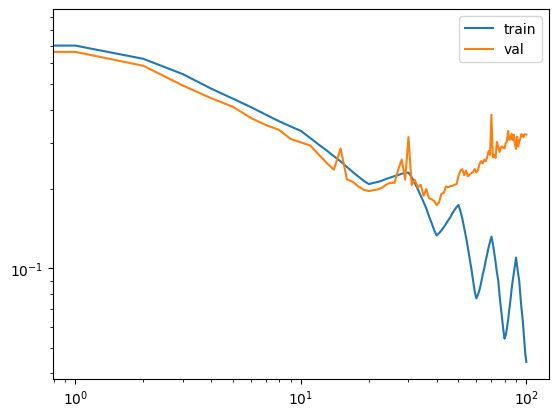

In [17]:
h = vgg_model.history.history
plt.yscale('log')
plt.xscale('log')
plt.plot(h['loss'])
plt.plot(h['val_loss'])
plt.legend(['train','val'])
plt.show()

In [7]:
Xt, Yt = synthetic_data_alignment(num_samples=10**5, num_features=256, seq_length=512, p_other=0.3)
vgg_model.load_weights('vgg_model_synthetic.keras')
Zt_vgg = vgg_model.predict(Xt,batch_size=32)

2024-11-03 01:00:26.020403: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8902


3125/3125 [==============================] - 5s 1ms/step


In [8]:
Zt_vgg_bin = Zt_vgg > 0.5

In [9]:
acc_vgg = np.mean(Zt_vgg_bin == Yt[:,0:32], axis=0)

In [10]:
acc_vgg

array([0.99985, 0.99953, 0.99942, 0.99896, 0.99835, 0.99752, 0.99629,
       0.99478, 0.99289, 0.99004, 0.98792, 0.98507, 0.98117, 0.97694,
       0.96992, 0.96026, 0.95183, 0.94395, 0.92831, 0.90962, 0.89365,
       0.87778, 0.86475, 0.85444, 0.84572, 0.83618, 0.83036, 0.82991,
       0.82366, 0.80467, 0.78335, 0.74326])

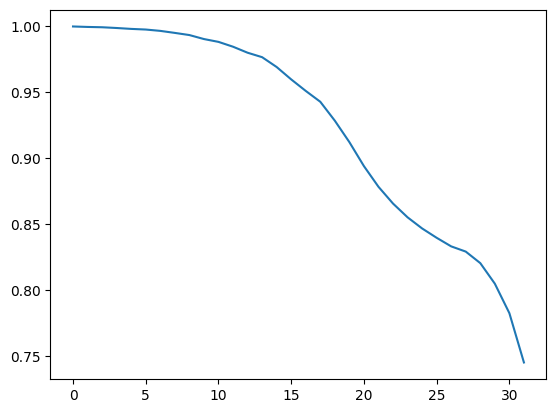

In [12]:
plt.plot(acc_vgg)

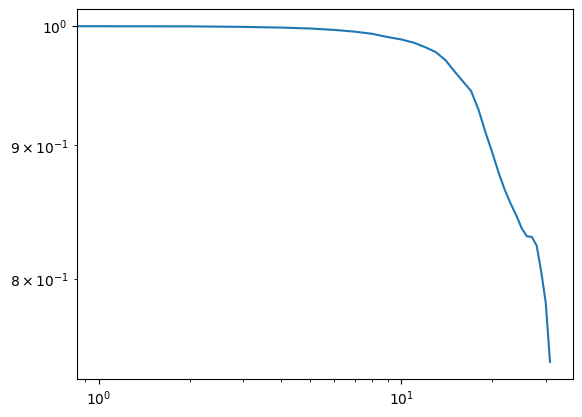

In [11]:
plt.yscale('log')
plt.xscale('log')
plt.plot(acc_vgg)


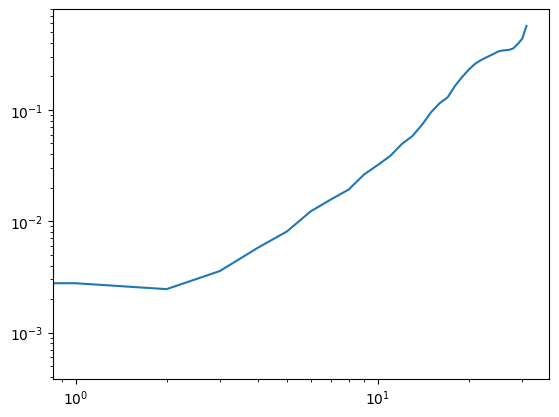

In [13]:
bce_vgg = -Yt[:,0:32] * np.log(Zt_vgg + 1e-7) - (1-Yt[:,0:32]) * np.log(1-Zt_vgg + 1e-7)
bce_vgg_mean = np.mean(bce_vgg, axis=0)

plt.yscale('log') 
plt.xscale('log')
plt.plot(bce_vgg_mean)


Linear regression on BCE log values:
Slope: 2.1308
Intercept: -8.2227
R-squared: 0.9708
P-value: 1.3814e-24
Standard error: 0.0674


Text(0.5, 1.0, 'Log-Log Plot with Linear Fit')

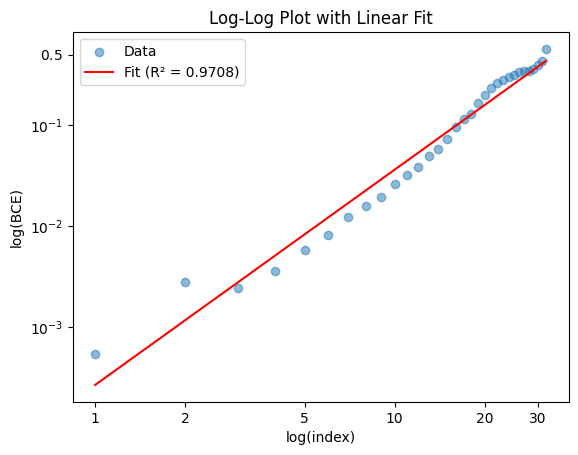

In [14]:
# Fit linear regression to BCE log values
from scipy import stats

# Take log of x and y values, dropping any infinite/nan values
x = np.log(np.arange(1, len(bce_vgg_mean)+1))
y = np.log(bce_vgg_mean)
mask = np.isfinite(x) & np.isfinite(y)
x = x[mask]
y = y[mask]

# Perform linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

print(f"Linear regression on BCE log values:")
print(f"Slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}") 
print(f"R-squared: {r_value**2:.4f}")
print(f"P-value: {p_value:.4e}")
print(f"Standard error: {std_err:.4f}")

# Plot regression line
plt.figure()
plt.gca().set_xticks([np.log(x) for x in [1, 2, 5, 10, 20, 30]])
plt.gca().set_xticklabels(['1', '2', '5', '10', '20', '30'])
plt.gca().set_yticks([np.log(y) for y in [0.001, 0.01, 0.1, 0.5, 0.9, 1]])
plt.gca().set_yticklabels(['$10^{-3}$','$10^{-2}$','$10^{-1}$','$0.5$','$0.9$','$1$'])
plt.scatter(np.log(np.arange(1, len(bce_vgg_mean)+1)), np.log(bce_vgg_mean), alpha=0.5, label='Data')
plt.plot(x, slope*x + intercept, 'r', label=f'Fit (R² = {r_value**2:.4f})')
plt.xlabel('log(index)')
plt.ylabel('log(BCE)')
plt.legend()
plt.title('Log-Log Plot with Linear Fit')

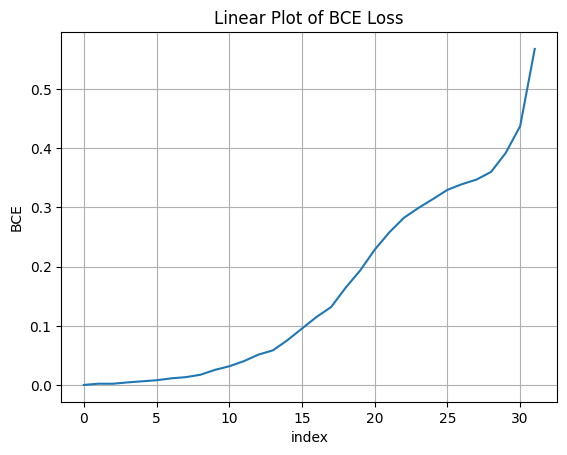

In [16]:
# Plot BCE loss on linear scale
plt.figure()
plt.plot(bce_vgg_mean)
plt.xlabel('index')
plt.ylabel('BCE')
plt.title('Linear Plot of BCE Loss')
plt.grid(True)


Fitted parameters:
a = 0.0241
e₀ = -0.9675


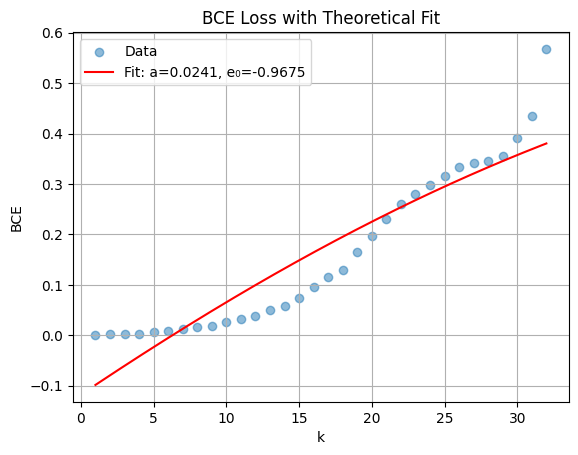

In [15]:
# Fit custom curve to BCE data
from scipy.optimize import curve_fit

def bce_model(k, a, e_0):
    # k is 1-based index, so subtract 1 to match data
    return -0.5 * np.log(0.25 - e_0 * np.exp(-2*a*(k-1)))

# Prepare data for fitting
k_data = np.arange(1, len(bce_vgg_mean)+1)
y_data = bce_vgg_mean

# Initial parameter guesses
p0 = [0.1, 0.1]  # Initial guesses for a and e_0

# Fit curve
try:
    popt, pcov = curve_fit(bce_model, k_data, y_data, p0=p0)
    a_fit, e0_fit = popt
    
    # Generate points for smooth curve
    k_smooth = np.linspace(1, len(bce_vgg_mean), 200)
    y_fit = bce_model(k_smooth, a_fit, e0_fit)
    
    # Plot results
    plt.figure()
    plt.scatter(k_data, y_data, alpha=0.5, label='Data')
    plt.plot(k_smooth, y_fit, 'r-', label=f'Fit: a={a_fit:.4f}, e₀={e0_fit:.4f}')
    plt.xlabel('k')
    plt.ylabel('BCE')
    plt.title('BCE Loss with Theoretical Fit')
    plt.legend()
    plt.grid(True)
    
    print(f"Fitted parameters:")
    print(f"a = {a_fit:.4f}")
    print(f"e₀ = {e0_fit:.4f}")
    
except RuntimeError:
    print("Error: Could not fit curve to data. Try adjusting initial parameters or model.")


Power Law parameters:
a = 0.0002
b = 2.2090


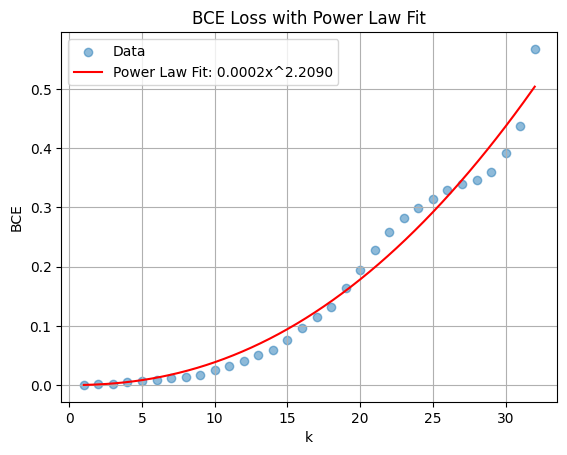

In [18]:
# Fit power law to BCE data
def power_law(x, a, b):
    return a * x**b

# Prepare data for power law fit
k_data = np.arange(1, len(bce_vgg_mean)+1)
y_data = bce_vgg_mean

# Fit power law curve
popt_power, pcov_power = curve_fit(power_law, k_data, y_data)
a_power, b_power = popt_power

# Generate points for smooth curve
k_smooth = np.linspace(1, len(bce_vgg_mean), 200)
y_fit_power = power_law(k_smooth, a_power, b_power)

# Plot results
plt.figure()
plt.scatter(k_data, y_data, alpha=0.5, label='Data')
plt.plot(k_smooth, y_fit_power, 'r-', label=f'Power Law Fit: {a_power:.4f}x^{b_power:.4f}')
plt.xlabel('k')
plt.ylabel('BCE')
plt.title('BCE Loss with Power Law Fit')
plt.legend()
plt.grid(True)

print(f"Power Law parameters:")
print(f"a = {a_power:.4f}")
print(f"b = {b_power:.4f}")


In [16]:
nc = ml.net_ches_2018(32, 8, 64, width=256, depth=20, output_activation='sigmoid')
nc.compile(optimizer='adam',loss='binary_crossentropy',metrics='binary_accuracy')
nc_check = ModelCheckpoint('nc_model_synthetic.keras', monitor='val_loss', save_best_only=True)

In [34]:
nc.fit(X,Y[:,0:32],epochs=21, batch_size=32,validation_split=0.1,callbacks=[lr_cyclic, nc_check])

Epoch 1/21
2813/2813 [==============================] - 46s 14ms/step - loss: 1.0439 - binary_accuracy: 0.5028 - val_loss: 0.7830 - val_binary_accuracy: 0.5050 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 37s 13ms/step - loss: 0.7600 - binary_accuracy: 0.5336 - val_loss: 0.7414 - val_binary_accuracy: 0.5522 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 39s 14ms/step - loss: 0.7291 - binary_accuracy: 0.5748 - val_loss: 0.7211 - val_binary_accuracy: 0.5754 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 42s 15ms/step - loss: 0.7034 - binary_accuracy: 0.5965 - val_loss: 0.6888 - val_binary_accuracy: 0.6001 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 42s 15ms/step - loss: 0.6725 - binary_accuracy: 0.6182 - val_loss: 0.6459 - val_binary_accuracy: 0.6276 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 41s 15ms/step - loss: 0.6310 - binary_accuracy: 0.6458 - va

In [17]:
nc.load_weights('nc_model_synthetic.keras')
Zt_nc = nc.predict(Xt,batch_size=32)

3125/3125 [==============================] - 12s 4ms/step


In [18]:
Zt_nc_bin = Zt_nc > 0.5

In [19]:
acc_nc = np.mean(Zt_nc_bin == Yt[:,0:32], axis=0)

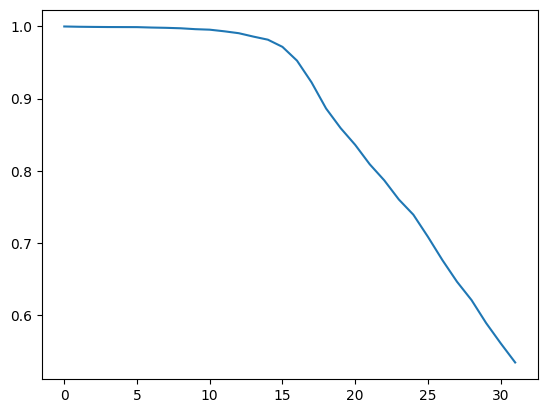

In [20]:
plt.plot(acc_nc)

Text(0.5, 1.0, 'Log-Log Plot of BCE Loss')

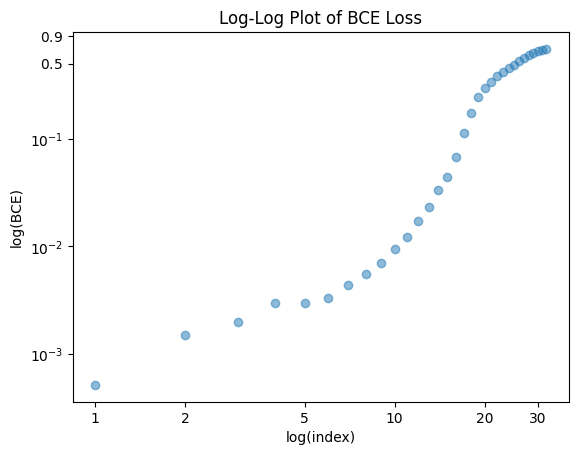

In [21]:
# Compute binary cross entropy loss for each bit position
bce_nc = []
for i in range(32):
    bce_nc.append(-Yt[:,i] * np.log(Zt_nc[:,i] + 1e-7) - (1-Yt[:,i]) * np.log(1-Zt_nc[:,i] + 1e-7))
bce_nc = np.array(bce_nc)

bce_nc_mean = np.mean(bce_nc, axis=0)
# Calculate mean BCE loss for each bit position
bce_nc_mean = np.mean(bce_nc, axis=1)  # Average across samples for each bit position

# Sort values from smallest to largest for clearer trend visualization
indices = np.argsort(bce_nc_mean)
bce_nc_mean = bce_nc_mean[indices]

# Remove any invalid values
valid_mask = ~np.isnan(bce_nc_mean) & ~np.isinf(bce_nc_mean) & (bce_nc_mean > 0)
bce_nc_mean = bce_nc_mean[valid_mask]


# Plot BCE loss on log-log scale
plt.figure()
plt.gca().set_xticks([np.log(x) for x in [1, 2, 5, 10, 20, 30]])
plt.gca().set_xticklabels(['1', '2', '5', '10', '20', '30'])
plt.gca().set_yticks([np.log(y) for y in [0.001, 0.01, 0.1, 0.5, 0.9, 1]])
plt.gca().set_yticklabels(['$10^{-3}$','$10^{-2}$','$10^{-1}$','$0.5$','$0.9$','$1$'])
plt.scatter(np.log(np.arange(1, len(bce_nc_mean)+1)), np.log(bce_nc_mean), alpha=0.5, label='Data')
plt.xlabel('log(index)')
plt.ylabel('log(BCE)')
plt.title('Log-Log Plot of BCE Loss')


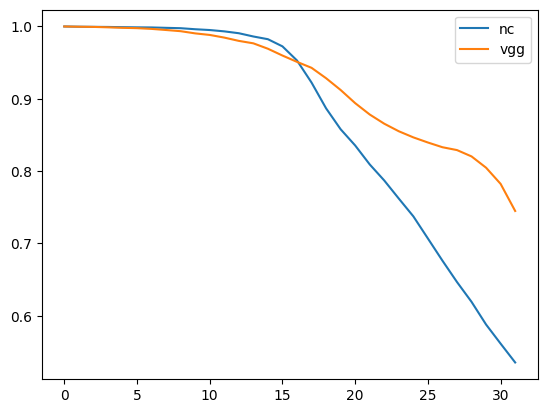

In [26]:
plt.plot(acc_nc[0:32])
plt.plot(acc_vgg)
plt.legend(["nc","vgg"])

Epoch 1/101
  56/2813 [..............................] - ETA: 2s - loss: 0.8889 - binary_accuracy: 0.4995   

2024-11-03 01:04:42.559970: I external/local_xla/xla/service/service.cc:168] XLA service 0x7111388ef610 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-11-03 01:04:42.559986: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 4070, Compute Capability 8.9
2024-11-03 01:04:42.568017: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1730549082.637907   41575 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2813/2813 [==============================] - 7s 2ms/step - loss: 0.7958 - binary_accuracy: 0.5003 - val_loss: 0.7861 - val_binary_accuracy: 0.5005 - lr: 1.0000e-05
Epoch 2/101
2813/2813 [==============================] - 7s 2ms/step - loss: 0.7588 - binary_accuracy: 0.5040 - val_loss: 0.7362 - val_binary_accuracy: 0.5075 - lr: 1.0900e-04
Epoch 3/101
2813/2813 [==============================] - 6s 2ms/step - loss: 0.7121 - binary_accuracy: 0.5183 - val_loss: 0.6991 - val_binary_accuracy: 0.5244 - lr: 2.0800e-04
Epoch 4/101
2813/2813 [==============================] - 4s 1ms/step - loss: 0.6914 - binary_accuracy: 0.5367 - val_loss: 0.6907 - val_binary_accuracy: 0.5359 - lr: 3.0700e-04
Epoch 5/101
2813/2813 [==============================] - 3s 1ms/step - loss: 0.6889 - binary_accuracy: 0.5417 - val_loss: 0.6912 - val_binary_accuracy: 0.5358 - lr: 4.0600e-04
Epoch 6/101
2813/2813 [==============================] - 5s 2ms/step - loss: 0.6900 - binary_accuracy: 0.5405 - val_loss: 0.6915 - v

Text(0, 0.5, 'Accuracy')

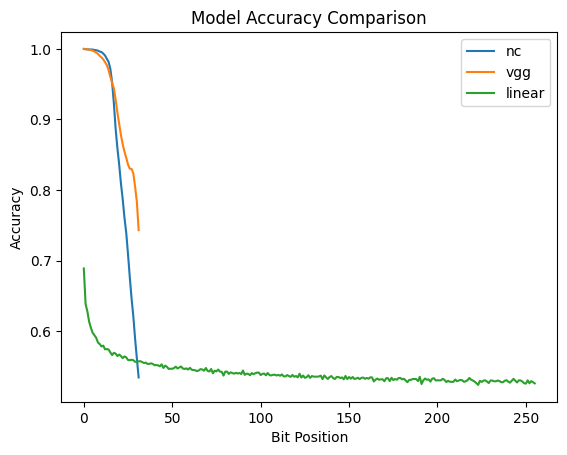

In [25]:
import tensorflow as tf

# Create and train a simple linear model
linear_model = tf.keras.Sequential([
    tf.keras.layers.Dense(256, activation='sigmoid', input_shape=(512,))
])

linear_model.compile(optimizer='adam', 
                    loss='binary_crossentropy',
                    metrics='binary_accuracy')

linear_model.fit(X, Y, epochs=101, batch_size=32, validation_split=0.1, callbacks=[lr_cyclic])

# Get predictions on test set
Zt_linear = linear_model.predict(Xt, batch_size=32)
Zt_linear_bin = Zt_linear > 0.5

# Calculate accuracy for each bit position
acc_linear = np.mean(Zt_linear_bin == Yt, axis=0)

# Plot comparison with other models
plt.figure()
plt.plot(acc_nc)
plt.plot(acc_vgg) 
plt.plot(acc_linear)
plt.legend(['nc', 'vgg', 'linear'])
plt.title('Model Accuracy Comparison')
plt.xlabel('Bit Position')
plt.ylabel('Accuracy')



In [31]:
# Calculate BCE losses for each model and position
bce = tf.keras.losses.BinaryCrossentropy()

# Calculate BCE for each position for each model
bce_nc = np.array([bce(Yt[:,i], Zt_nc_bin[:,i]).numpy() for i in range(256)])
bce_vgg = np.array([bce(Yt[:,i], Zt_vgg_bin[:,i]).numpy() for i in range(256)])
bce_linear = np.array([bce(Yt[:,i], Zt_linear_bin[:,i]).numpy() for i in range(256)])

# Create log-log plot
plt.figure()
plt.clf() # Clear the current figure to avoid any potential issues with boolean tensors
plt.loglog(range(1,257), bce_nc, label='nc')
plt.loglog(range(1,257), bce_vgg, label='vgg')
plt.loglog(range(1,257), bce_linear, label='linear')
plt.legend()
plt.title('Log-Log Plot of BCE Loss')
plt.xlabel('Bit Position (log scale)')
plt.ylabel('BCE Loss (log scale)')


TypeError: Cannot convert 0.0 to EagerTensor of dtype bool

In [53]:
vgg_model = ml.VGG_1D(512, 256, [32,64,128,128],[512,512,512], output_activation='sigmoid',dense_batch_norm=True)

In [54]:
vgg_model.compile(optimizer='adam',loss='binary_crossentropy',metrics='binary_accuracy')

In [55]:
vgg_model.fit(X,Y, epochs=101, batch_size=32, validation_split=0.1, callbacks=[lr_cyclic])

Epoch 1/101
2813/2813 [==============================] - 22s 7ms/step - loss: 0.8141 - binary_accuracy: 0.5032 - val_loss: 0.7963 - val_binary_accuracy: 0.5070 - lr: 1.0000e-05
Epoch 2/101
2813/2813 [==============================] - 24s 8ms/step - loss: 0.7081 - binary_accuracy: 0.5463 - val_loss: 0.6812 - val_binary_accuracy: 0.5705 - lr: 1.0900e-04
Epoch 3/101
2813/2813 [==============================] - 25s 9ms/step - loss: 0.6768 - binary_accuracy: 0.5775 - val_loss: 0.6714 - val_binary_accuracy: 0.5865 - lr: 2.0800e-04
Epoch 4/101
2813/2813 [==============================] - 22s 8ms/step - loss: 0.6632 - binary_accuracy: 0.5988 - val_loss: 0.6506 - val_binary_accuracy: 0.6157 - lr: 3.0700e-04
Epoch 5/101
2813/2813 [==============================] - 20s 7ms/step - loss: 0.6460 - binary_accuracy: 0.6192 - val_loss: 0.6395 - val_binary_accuracy: 0.6261 - lr: 4.0600e-04
Epoch 6/101
2813/2813 [==============================] - 24s 9ms/step - loss: 0.6358 - binary_accuracy: 0.6297 - va

In [56]:
Zt_vgg = vgg_model.predict(Xt,batch_size=32)

3125/3125 [==============================] - 4s 1ms/step


In [57]:
Zt_vgg_bin = Zt_vgg > 0.5

In [58]:
acc_vgg = np.mean(Zt_vgg_bin == Yt, axis=0)

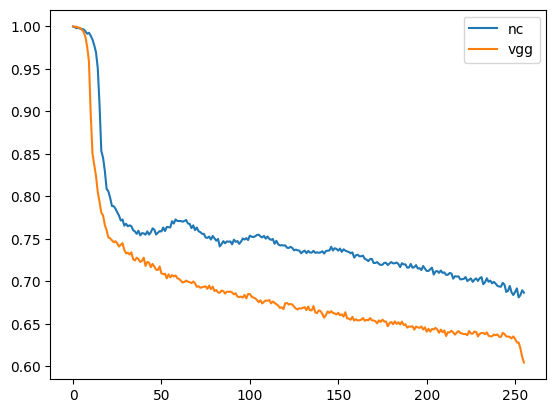

In [59]:
plt.plot(acc_nc)
plt.plot(acc_vgg)
plt.legend(['nc','vgg'])

In [60]:
nc.summary()

Model: "model_5"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_6 (InputLayer)        [(None, 512)]                0         []                            
                                                                                                  
 reshape_5 (Reshape)         (None, 8, 64)                0         ['input_6[0][0]']             
                                                                                                  
 batch_normalization_35 (Ba  (None, 8, 64)                256       ['reshape_5[0][0]']           
 tchNormalization)                                                                                
                                                                                                  
 conv1d_20 (Conv1D)          (None, 8, 256)               16640     ['batch_normalization_35

In [62]:
vgg_model.summary()

Model: "model_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_12 (InputLayer)       [(None, 512)]             0         
                                                                 
 reshape_6 (Reshape)         (None, 512, 1)            0         
                                                                 
 conv1d_122 (Conv1D)         (None, 512, 32)           128       
                                                                 
 batch_normalization_132 (B  (None, 512, 32)           128       
 atchNormalization)                                              
                                                                 
 max_pooling1d_48 (MaxPooli  (None, 256, 32)           0         
 ng1D)                                                           
                                                                 
 conv1d_123 (Conv1D)         (None, 256, 64)           6208

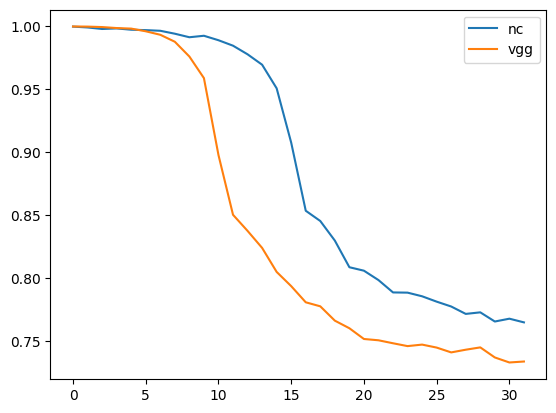

In [63]:
plt.plot(acc_nc[0:32])
plt.plot(acc_vgg[0:32])
plt.legend(['nc','vgg'])

In [64]:
nc.fit(X,Y,epochs=21, batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 37s 13ms/step - loss: 0.5211 - binary_accuracy: 0.7333 - val_loss: 0.4958 - val_binary_accuracy: 0.7532 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 34s 12ms/step - loss: 0.5239 - binary_accuracy: 0.7314 - val_loss: 0.5040 - val_binary_accuracy: 0.7458 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 37s 13ms/step - loss: 0.5283 - binary_accuracy: 0.7282 - val_loss: 0.4999 - val_binary_accuracy: 0.7504 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 35s 12ms/step - loss: 0.5336 - binary_accuracy: 0.7245 - val_loss: 0.5156 - val_binary_accuracy: 0.7377 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 33s 12ms/step - loss: 0.5371 - binary_accuracy: 0.7223 - val_loss: 0.5219 - val_binary_accuracy: 0.7336 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 35s 12ms/step - loss: 0.5419 - binary_accuracy: 0.7194 - va

In [65]:
Zt_nc2 = nc.predict(Xt,batch_size=32)

3125/3125 [==============================] - 11s 3ms/step


In [66]:
Zt_nc2_bin = Zt_nc2 > 0.5

In [67]:
acc_nc2 = np.mean(Zt_nc2_bin == Yt, axis=0)

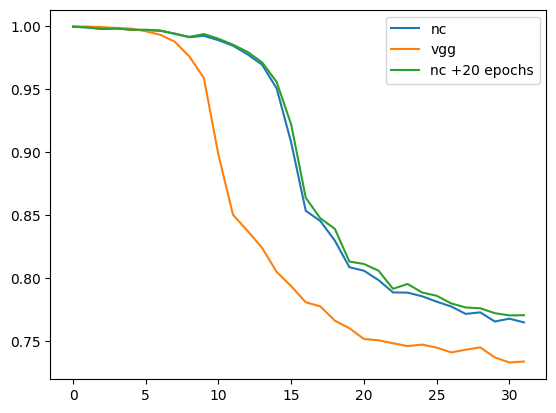

In [68]:
plt.plot(acc_nc[0:32])
plt.plot(acc_vgg[0:32])
plt.plot(acc_nc2[0:32])
plt.legend(['nc','vgg','nc +20 epochs'])

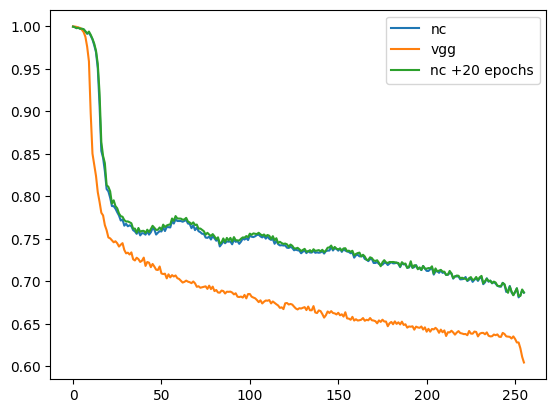

In [69]:
plt.plot(acc_nc)
plt.plot(acc_vgg)
plt.plot(acc_nc2)
plt.legend(['nc','vgg','nc +20 epochs'])

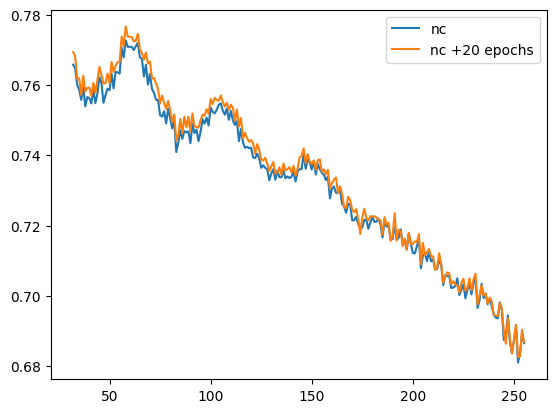

In [72]:
plt.plot(np.arange(32,256),acc_nc[32:])
plt.plot(np.arange(32,256),acc_nc2[32:])
plt.legend(['nc','nc +20 epochs'])

In [102]:
import Transformer
reload(Transformer)
model = Transformer.create_transformer_model((512,), 1, 128, 5, 64, output_activation='sigmoid',outputs=8, dense_nodes=512)

In [103]:
model.summary()

Model: "model_17"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_31 (InputLayer)       [(None, 512, 1)]          0         
                                                                 
 conv1d_135 (Conv1D)         (None, 512, 128)          2304      
                                                                 
 token_and_position_embeddi  (None, 512, 128)          82048     
 ng_8 (TokenAndPositionEmbe                                      
 dding)                                                          
                                                                 
 transformer_block_62 (Tran  (None, 512, 128)          347072    
 sformerBlock)                                                   
                                                                 
 global_max_pooling1d_8 (Gl  (None, 128)               0         
 obalMaxPooling1D)                                        

In [104]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics='binary_accuracy')
model.fit(X,Y[:,0:8],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 63s 22ms/step - loss: 0.7030 - binary_accuracy: 0.5064 - val_loss: 0.6931 - val_binary_accuracy: 0.5109 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 65s 23ms/step - loss: 0.4796 - binary_accuracy: 0.7366 - val_loss: 0.3531 - val_binary_accuracy: 0.8184 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 64s 23ms/step - loss: 0.2266 - binary_accuracy: 0.8892 - val_loss: 0.0821 - val_binary_accuracy: 0.9664 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 64s 23ms/step - loss: 0.0480 - binary_accuracy: 0.9804 - val_loss: 0.0352 - val_binary_accuracy: 0.9850 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 66s 23ms/step - loss: 0.0289 - binary_accuracy: 0.9884 - val_loss: 0.0287 - val_binary_accuracy: 0.9873 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 64s 23ms/step - loss: 0.0267 - binary_accuracy: 0.9896 - va

In [105]:
model.fit(X,Y[:,8:16],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 61s 22ms/step - loss: 0.8896 - binary_accuracy: 0.5059 - val_loss: 1.5784 - val_binary_accuracy: 0.4994 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 67s 24ms/step - loss: 0.5605 - binary_accuracy: 0.6483 - val_loss: 0.4984 - val_binary_accuracy: 0.7244 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 66s 24ms/step - loss: 0.3265 - binary_accuracy: 0.8194 - val_loss: 0.2620 - val_binary_accuracy: 0.8613 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 61s 22ms/step - loss: 0.1785 - binary_accuracy: 0.9109 - val_loss: 0.0817 - val_binary_accuracy: 0.9643 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 63s 22ms/step - loss: 0.0709 - binary_accuracy: 0.9673 - val_loss: 0.0488 - val_binary_accuracy: 0.9787 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 66s 23ms/step - loss: 0.0515 - binary_accuracy: 0.9757 - va

In [106]:
model.fit(X,Y[:,16:24],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 64s 23ms/step - loss: 1.0201 - binary_accuracy: 0.5081 - val_loss: 0.7707 - val_binary_accuracy: 0.5136 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 64s 23ms/step - loss: 0.6250 - binary_accuracy: 0.6126 - val_loss: 0.7668 - val_binary_accuracy: 0.6510 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 67s 24ms/step - loss: 0.4495 - binary_accuracy: 0.7446 - val_loss: 0.5374 - val_binary_accuracy: 0.7693 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 67s 24ms/step - loss: 0.3265 - binary_accuracy: 0.8189 - val_loss: 0.3791 - val_binary_accuracy: 0.8463 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 67s 24ms/step - loss: 0.2171 - binary_accuracy: 0.8846 - val_loss: 0.2143 - val_binary_accuracy: 0.9089 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 68s 24ms/step - loss: 0.1523 - binary_accuracy: 0.9173 - va

In [109]:
vgg_model = ml.VGG_1D(512, 8, [32,64,128,128],[512,512,512], output_activation='sigmoid',dense_batch_norm=True)
vgg_model.compile(optimizer='adam',loss='binary_crossentropy',metrics='binary_accuracy')

In [110]:
vgg_model.fit(X,Y[:,0:8],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 26s 9ms/step - loss: 0.8172 - binary_accuracy: 0.5177 - val_loss: 0.7696 - val_binary_accuracy: 0.5365 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 22s 8ms/step - loss: 0.6472 - binary_accuracy: 0.6337 - val_loss: 0.5424 - val_binary_accuracy: 0.7053 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 23s 8ms/step - loss: 0.4171 - binary_accuracy: 0.7854 - val_loss: 0.2968 - val_binary_accuracy: 0.8543 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 21s 7ms/step - loss: 0.2315 - binary_accuracy: 0.8894 - val_loss: 0.1440 - val_binary_accuracy: 0.9346 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 22s 8ms/step - loss: 0.1264 - binary_accuracy: 0.9456 - val_loss: 0.0779 - val_binary_accuracy: 0.9688 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 23s 8ms/step - loss: 0.0779 - binary_accuracy: 0.9694 - val_loss

In [111]:
vgg_model.fit(X,Y[:,8:16],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 26s 9ms/step - loss: 5.1936 - binary_accuracy: 0.5117 - val_loss: 3.0023 - val_binary_accuracy: 0.5286 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 23s 8ms/step - loss: 0.9596 - binary_accuracy: 0.5545 - val_loss: 0.6842 - val_binary_accuracy: 0.5864 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 24s 8ms/step - loss: 0.6162 - binary_accuracy: 0.6386 - val_loss: 0.6869 - val_binary_accuracy: 0.7107 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 24s 9ms/step - loss: 0.4946 - binary_accuracy: 0.7390 - val_loss: 0.4581 - val_binary_accuracy: 0.7849 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 22s 8ms/step - loss: 0.4024 - binary_accuracy: 0.7971 - val_loss: 0.6761 - val_binary_accuracy: 0.8372 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 24s 9ms/step - loss: 0.3312 - binary_accuracy: 0.8396 - val_loss

In [112]:
vgg_model.fit(X,Y[:,16:24],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 24s 9ms/step - loss: 3.3721 - binary_accuracy: 0.5031 - val_loss: 2.4870 - val_binary_accuracy: 0.5076 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 24s 9ms/step - loss: 0.9870 - binary_accuracy: 0.5320 - val_loss: 0.7508 - val_binary_accuracy: 0.5671 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 24s 9ms/step - loss: 0.6618 - binary_accuracy: 0.6014 - val_loss: 0.6282 - val_binary_accuracy: 0.6421 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 23s 8ms/step - loss: 0.5866 - binary_accuracy: 0.6734 - val_loss: 0.5675 - val_binary_accuracy: 0.7167 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 23s 8ms/step - loss: 0.5153 - binary_accuracy: 0.7289 - val_loss: 0.4882 - val_binary_accuracy: 0.7646 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 23s 8ms/step - loss: 0.4546 - binary_accuracy: 0.7703 - val_loss

In [113]:
model.fit(X,Y[:,24:32],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 67s 24ms/step - loss: 1.0895 - binary_accuracy: 0.5019 - val_loss: 1.8602 - val_binary_accuracy: 0.5039 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 65s 23ms/step - loss: 0.6757 - binary_accuracy: 0.5581 - val_loss: 3.3160 - val_binary_accuracy: 0.5284 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 62s 22ms/step - loss: 0.5807 - binary_accuracy: 0.6659 - val_loss: 1.6872 - val_binary_accuracy: 0.6188 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 63s 22ms/step - loss: 0.4094 - binary_accuracy: 0.7750 - val_loss: 0.9099 - val_binary_accuracy: 0.7583 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 65s 23ms/step - loss: 0.2534 - binary_accuracy: 0.8554 - val_loss: 0.6800 - val_binary_accuracy: 0.8335 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 67s 24ms/step - loss: 0.2068 - binary_accuracy: 0.8841 - va

In [114]:
vgg_model.fit(X,Y[:,24:32],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 22s 8ms/step - loss: 2.2068 - binary_accuracy: 0.5065 - val_loss: 1.5273 - val_binary_accuracy: 0.5151 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 23s 8ms/step - loss: 0.8349 - binary_accuracy: 0.5452 - val_loss: 0.7405 - val_binary_accuracy: 0.5852 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 22s 8ms/step - loss: 0.6688 - binary_accuracy: 0.6104 - val_loss: 0.6518 - val_binary_accuracy: 0.6489 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 23s 8ms/step - loss: 0.6142 - binary_accuracy: 0.6629 - val_loss: 0.6005 - val_binary_accuracy: 0.6928 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 24s 9ms/step - loss: 0.5733 - binary_accuracy: 0.6984 - val_loss: 0.5809 - val_binary_accuracy: 0.7236 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 23s 8ms/step - loss: 0.5361 - binary_accuracy: 0.7241 - val_loss

In [116]:
model.fit(X,Y[:,32:40],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 65s 23ms/step - loss: 0.8116 - binary_accuracy: 0.5040 - val_loss: 3.5154 - val_binary_accuracy: 0.5059 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 65s 23ms/step - loss: 0.5790 - binary_accuracy: 0.6288 - val_loss: 4.0867 - val_binary_accuracy: 0.6034 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 62s 22ms/step - loss: 0.4656 - binary_accuracy: 0.7000 - val_loss: 3.3425 - val_binary_accuracy: 0.6427 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 66s 24ms/step - loss: 0.4424 - binary_accuracy: 0.7105 - val_loss: 2.9307 - val_binary_accuracy: 0.6625 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 66s 24ms/step - loss: 0.4287 - binary_accuracy: 0.7160 - val_loss: 2.9809 - val_binary_accuracy: 0.6855 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 65s 23ms/step - loss: 0.6051 - binary_accuracy: 0.5723 - va

In [117]:
vgg_model.fit(X,Y[:,32:40],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 21s 8ms/step - loss: 1.4712 - binary_accuracy: 0.5068 - val_loss: 1.1647 - val_binary_accuracy: 0.5167 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 24s 8ms/step - loss: 0.7555 - binary_accuracy: 0.5589 - val_loss: 0.7337 - val_binary_accuracy: 0.6012 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 22s 8ms/step - loss: 0.6533 - binary_accuracy: 0.6261 - val_loss: 0.6393 - val_binary_accuracy: 0.6628 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 23s 8ms/step - loss: 0.6001 - binary_accuracy: 0.6735 - val_loss: 0.5628 - val_binary_accuracy: 0.7028 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 22s 8ms/step - loss: 0.5580 - binary_accuracy: 0.7075 - val_loss: 0.5305 - val_binary_accuracy: 0.7335 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 22s 8ms/step - loss: 0.5302 - binary_accuracy: 0.7272 - val_loss

In [118]:
vgg_model.summary()

Model: "model_19"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_33 (InputLayer)       [(None, 512)]             0         
                                                                 
 reshape_18 (Reshape)        (None, 512, 1)            0         
                                                                 
 conv1d_140 (Conv1D)         (None, 512, 32)           128       
                                                                 
 batch_normalization_146 (B  (None, 512, 32)           128       
 atchNormalization)                                              
                                                                 
 max_pooling1d_56 (MaxPooli  (None, 256, 32)           0         
 ng1D)                                                           
                                                                 
 conv1d_141 (Conv1D)         (None, 256, 64)           620

In [119]:
model.summary()

Model: "model_17"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_31 (InputLayer)       [(None, 512, 1)]          0         
                                                                 
 conv1d_135 (Conv1D)         (None, 512, 128)          2304      
                                                                 
 token_and_position_embeddi  (None, 512, 128)          82048     
 ng_8 (TokenAndPositionEmbe                                      
 dding)                                                          
                                                                 
 transformer_block_62 (Tran  (None, 512, 128)          347072    
 sformerBlock)                                                   
                                                                 
 global_max_pooling1d_8 (Gl  (None, 128)               0         
 obalMaxPooling1D)                                        

In [120]:
vgg_model.fit(X,Y[:,32:40],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 24s 9ms/step - loss: 0.2899 - binary_accuracy: 0.8746 - val_loss: 0.3474 - val_binary_accuracy: 0.8446 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 18s 6ms/step - loss: 0.2959 - binary_accuracy: 0.8714 - val_loss: 0.3523 - val_binary_accuracy: 0.8434 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 20s 7ms/step - loss: 0.2970 - binary_accuracy: 0.8709 - val_loss: 0.3589 - val_binary_accuracy: 0.8416 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 23s 8ms/step - loss: 0.3045 - binary_accuracy: 0.8669 - val_loss: 0.3623 - val_binary_accuracy: 0.8381 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 25s 9ms/step - loss: 0.3045 - binary_accuracy: 0.8670 - val_loss: 0.3837 - val_binary_accuracy: 0.8310 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 24s 9ms/step - loss: 0.3086 - binary_accuracy: 0.8654 - val_loss

In [121]:
vgg_model.fit(X,Y[:,40:48],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 26s 9ms/step - loss: 1.8404 - binary_accuracy: 0.5072 - val_loss: 1.4913 - val_binary_accuracy: 0.5143 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 23s 8ms/step - loss: 0.8391 - binary_accuracy: 0.5493 - val_loss: 0.7086 - val_binary_accuracy: 0.5911 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 26s 9ms/step - loss: 0.6683 - binary_accuracy: 0.6165 - val_loss: 0.6760 - val_binary_accuracy: 0.6546 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 21s 7ms/step - loss: 0.6079 - binary_accuracy: 0.6706 - val_loss: 0.5754 - val_binary_accuracy: 0.7007 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 28s 10ms/step - loss: 0.5639 - binary_accuracy: 0.7053 - val_loss: 0.5281 - val_binary_accuracy: 0.7310 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 27s 9ms/step - loss: 0.5369 - binary_accuracy: 0.7239 - val_los

In [123]:
vgg_model2 = ml.VGG_1D(512, 8, [32,64,128,128],[512,512,512], output_activation='sigmoid',dense_batch_norm=True)
vgg_model2.compile(optimizer='adam',loss='binary_crossentropy',metrics='binary_accuracy')
vgg_model2.fit(X,Y[:,40:48],epochs=101,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/101
2813/2813 [==============================] - 23s 8ms/step - loss: 0.8241 - binary_accuracy: 0.5119 - val_loss: 0.7871 - val_binary_accuracy: 0.5212 - lr: 1.0000e-05
Epoch 2/101
2813/2813 [==============================] - 21s 8ms/step - loss: 0.7182 - binary_accuracy: 0.5594 - val_loss: 0.7052 - val_binary_accuracy: 0.5683 - lr: 1.0900e-04
Epoch 3/101
2813/2813 [==============================] - 23s 8ms/step - loss: 0.6701 - binary_accuracy: 0.6030 - val_loss: 0.6712 - val_binary_accuracy: 0.6076 - lr: 2.0800e-04
Epoch 4/101
2813/2813 [==============================] - 23s 8ms/step - loss: 0.6466 - binary_accuracy: 0.6285 - val_loss: 0.6437 - val_binary_accuracy: 0.6316 - lr: 3.0700e-04
Epoch 5/101
2813/2813 [==============================] - 22s 8ms/step - loss: 0.6302 - binary_accuracy: 0.6450 - val_loss: 0.6200 - val_binary_accuracy: 0.6530 - lr: 4.0600e-04
Epoch 6/101
2813/2813 [==============================] - 20s 7ms/step - loss: 0.6094 - binary_accuracy: 0.6632 - va

In [124]:
vgg_model.fit(X,Y[:,40:48],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 22s 8ms/step - loss: 0.3082 - binary_accuracy: 0.8660 - val_loss: 0.4199 - val_binary_accuracy: 0.8104 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 19s 7ms/step - loss: 0.3126 - binary_accuracy: 0.8635 - val_loss: 0.4327 - val_binary_accuracy: 0.8077 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 22s 8ms/step - loss: 0.3172 - binary_accuracy: 0.8609 - val_loss: 0.4298 - val_binary_accuracy: 0.8067 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 25s 9ms/step - loss: 0.3186 - binary_accuracy: 0.8603 - val_loss: 0.4291 - val_binary_accuracy: 0.8069 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 22s 8ms/step - loss: 0.3219 - binary_accuracy: 0.8582 - val_loss: 0.4519 - val_binary_accuracy: 0.7956 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 24s 8ms/step - loss: 0.3243 - binary_accuracy: 0.8578 - val_loss

In [125]:
vgg_model.fit(X,Y[:,48:56],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 23s 8ms/step - loss: 1.7086 - binary_accuracy: 0.5091 - val_loss: 1.4349 - val_binary_accuracy: 0.5148 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 19s 7ms/step - loss: 0.8409 - binary_accuracy: 0.5466 - val_loss: 0.7251 - val_binary_accuracy: 0.5848 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 20s 7ms/step - loss: 0.6706 - binary_accuracy: 0.6135 - val_loss: 0.6592 - val_binary_accuracy: 0.6485 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 21s 7ms/step - loss: 0.6191 - binary_accuracy: 0.6596 - val_loss: 0.5809 - val_binary_accuracy: 0.6899 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 19s 7ms/step - loss: 0.5786 - binary_accuracy: 0.6925 - val_loss: 0.5505 - val_binary_accuracy: 0.7167 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 22s 8ms/step - loss: 0.5525 - binary_accuracy: 0.7107 - val_loss

In [126]:
vgg_model.fit(X,Y[:,56:64],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 24s 8ms/step - loss: 1.1682 - binary_accuracy: 0.5092 - val_loss: 1.0052 - val_binary_accuracy: 0.5168 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 19s 7ms/step - loss: 0.7452 - binary_accuracy: 0.5605 - val_loss: 0.6813 - val_binary_accuracy: 0.6024 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 24s 9ms/step - loss: 0.6492 - binary_accuracy: 0.6280 - val_loss: 0.6183 - val_binary_accuracy: 0.6633 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 24s 8ms/step - loss: 0.6026 - binary_accuracy: 0.6702 - val_loss: 0.5764 - val_binary_accuracy: 0.6986 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 24s 8ms/step - loss: 0.5712 - binary_accuracy: 0.6949 - val_loss: 0.5423 - val_binary_accuracy: 0.7169 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 26s 9ms/step - loss: 0.5506 - binary_accuracy: 0.7097 - val_loss

In [127]:
vgg_model.fit(X,Y[:,64:72],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 25s 9ms/step - loss: 1.0685 - binary_accuracy: 0.5120 - val_loss: 0.9522 - val_binary_accuracy: 0.5228 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 24s 9ms/step - loss: 0.7258 - binary_accuracy: 0.5655 - val_loss: 0.8493 - val_binary_accuracy: 0.6099 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 21s 7ms/step - loss: 0.6475 - binary_accuracy: 0.6281 - val_loss: 0.6601 - val_binary_accuracy: 0.6660 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 24s 8ms/step - loss: 0.6034 - binary_accuracy: 0.6676 - val_loss: 0.5845 - val_binary_accuracy: 0.6995 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 23s 8ms/step - loss: 0.5728 - binary_accuracy: 0.6923 - val_loss: 0.5330 - val_binary_accuracy: 0.7204 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 20s 7ms/step - loss: 0.5545 - binary_accuracy: 0.7065 - val_loss

In [128]:
vgg_model.fit(X,Y[:,72:80],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 26s 9ms/step - loss: 1.0477 - binary_accuracy: 0.5116 - val_loss: 0.9616 - val_binary_accuracy: 0.5197 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 23s 8ms/step - loss: 0.7285 - binary_accuracy: 0.5610 - val_loss: 0.7271 - val_binary_accuracy: 0.6022 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 22s 8ms/step - loss: 0.6448 - binary_accuracy: 0.6279 - val_loss: 0.7072 - val_binary_accuracy: 0.6637 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 22s 8ms/step - loss: 0.6004 - binary_accuracy: 0.6683 - val_loss: 0.5726 - val_binary_accuracy: 0.6978 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 26s 9ms/step - loss: 0.5751 - binary_accuracy: 0.6893 - val_loss: 0.5480 - val_binary_accuracy: 0.7100 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 23s 8ms/step - loss: 0.5560 - binary_accuracy: 0.7031 - val_loss

In [132]:
pos = np.zeros(len(X), dtype=int)
X2 = np.copy(X)
X2 = X2.astype(float)
for i in range(512):
    tmp = X[:,i]
    tmp = (tmp != 2)
    pos = pos + tmp
    X2[:,i] = X2[:,i] + pos/256.0

In [133]:
X2[0][0:10]

array([2.        , 0.00390625, 0.0078125 , 1.01171875, 0.015625  ,
       2.015625  , 0.01953125, 0.0234375 , 2.0234375 , 0.02734375])

In [134]:
vgg_model3 = ml.VGG_1D(512, 8, [32,64,128,128],[512,512,512], output_activation='sigmoid',dense_batch_norm=True)
vgg_model3.compile(optimizer='adam',loss='binary_crossentropy',metrics='binary_accuracy')
vgg_model3.fit(X2,Y[:,128:136],epochs=101,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/101
2813/2813 [==============================] - 29s 9ms/step - loss: 0.8288 - binary_accuracy: 0.5067 - val_loss: 0.7951 - val_binary_accuracy: 0.5091 - lr: 1.0000e-05
Epoch 2/101
2813/2813 [==============================] - 22s 8ms/step - loss: 0.7323 - binary_accuracy: 0.5372 - val_loss: 0.7211 - val_binary_accuracy: 0.5422 - lr: 1.0900e-04
Epoch 3/101
2813/2813 [==============================] - 24s 8ms/step - loss: 0.6888 - binary_accuracy: 0.5735 - val_loss: 0.6953 - val_binary_accuracy: 0.5629 - lr: 2.0800e-04
Epoch 4/101
2813/2813 [==============================] - 25s 9ms/step - loss: 0.6710 - binary_accuracy: 0.5948 - val_loss: 0.6737 - val_binary_accuracy: 0.5923 - lr: 3.0700e-04
Epoch 5/101
2813/2813 [==============================] - 28s 10ms/step - loss: 0.6587 - binary_accuracy: 0.6109 - val_loss: 0.6523 - val_binary_accuracy: 0.6201 - lr: 4.0600e-04
Epoch 6/101
2813/2813 [==============================] - 25s 9ms/step - loss: 0.6491 - binary_accuracy: 0.6234 - v

In [135]:
vgg_model2.set_weights(vgg_model3.get_weights())    

In [137]:
vgg_model2.evaluate(X2,Y[:,128:136],batch_size=32)
vgg_model2.evaluate(X,Y[:,128:136],batch_size=32)
vgg_model2.fit(X,Y[:,128:136],epochs=101,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

3125/3125 [==============================] - 7s 2ms/step - loss: 135407.7812 - binary_accuracy: 0.4990
Epoch 1/101
2813/2813 [==============================] - 26s 9ms/step - loss: 2.1142 - binary_accuracy: 0.5002 - val_loss: 3.0639 - val_binary_accuracy: 0.5023 - lr: 1.0000e-05
Epoch 2/101
2813/2813 [==============================] - 26s 9ms/step - loss: 1.0732 - binary_accuracy: 0.5033 - val_loss: 1.7311 - val_binary_accuracy: 0.5086 - lr: 1.0900e-04
Epoch 3/101
2813/2813 [==============================] - 25s 9ms/step - loss: 0.7656 - binary_accuracy: 0.5065 - val_loss: 3.2561 - val_binary_accuracy: 0.5126 - lr: 2.0800e-04
Epoch 4/101
2813/2813 [==============================] - 26s 9ms/step - loss: 0.7195 - binary_accuracy: 0.5205 - val_loss: 2.8232 - val_binary_accuracy: 0.5318 - lr: 3.0700e-04
Epoch 5/101
2813/2813 [==============================] - 26s 9ms/step - loss: 0.7040 - binary_accuracy: 0.5380 - val_loss: 2.2800 - val_binary_accuracy: 0.5473 - lr: 4.0600e-04
Epoch 6/101
